ARTI308 - Machine Learning

## Linear Regression

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

 ### 1. Load the dataset

In [10]:
customers = pd.read_csv('Ecommerce Customers')

### 2. Explore the data

In [24]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [25]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [26]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### EDA

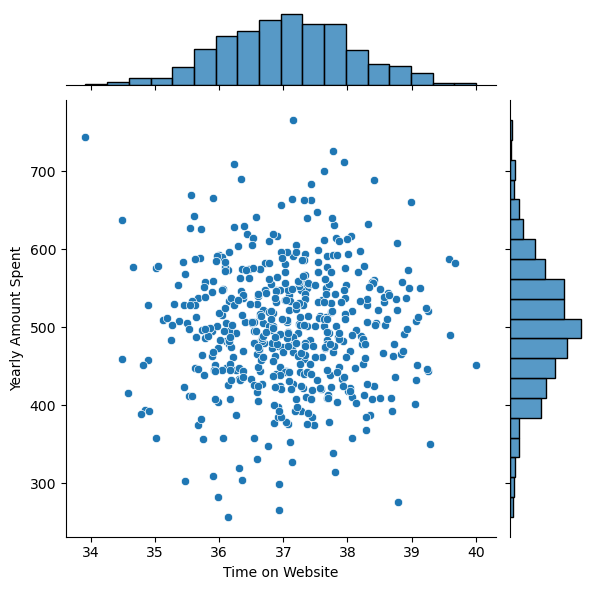

In [11]:
# Comparing Time on Website and Yearly Amount Spent
sns.jointplot(x='Time on Website', y='Yearly Amount Spent', data=customers)
plt.show()

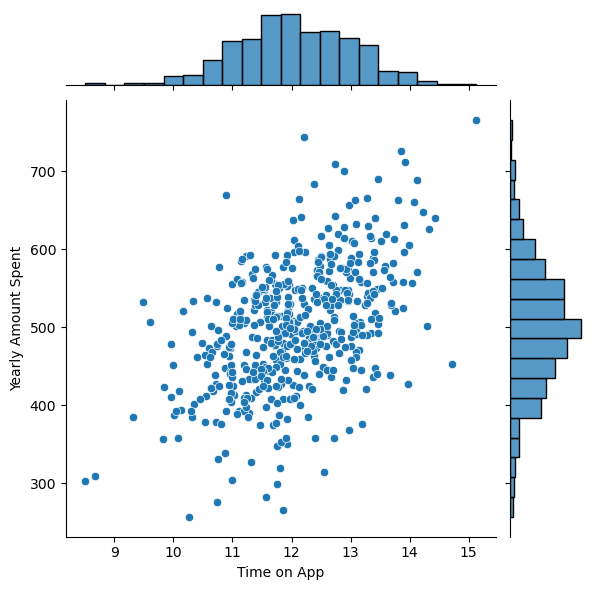

In [12]:
# Comparing Time on App and Yearly Amount Spent
sns.jointplot(x='Time on App', y='Yearly Amount Spent', data=customers)
plt.show()

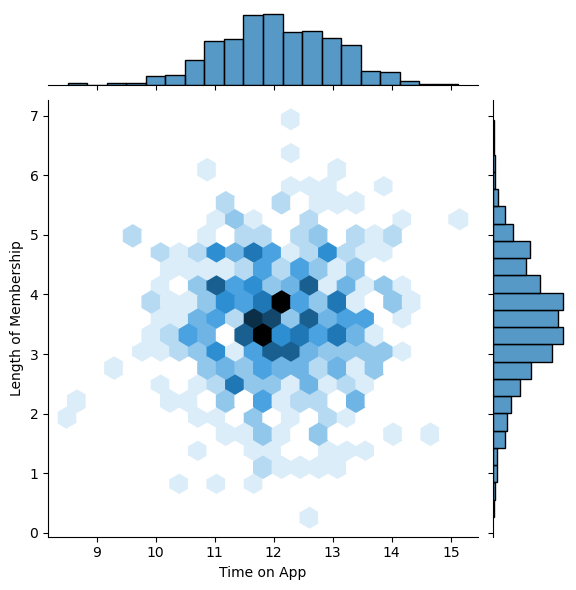

In [13]:
# 2D hex bin plot comparing Time on App and Length of Membership
sns.jointplot(x='Time on App', y='Length of Membership', kind='hex', data=customers)
plt.show()

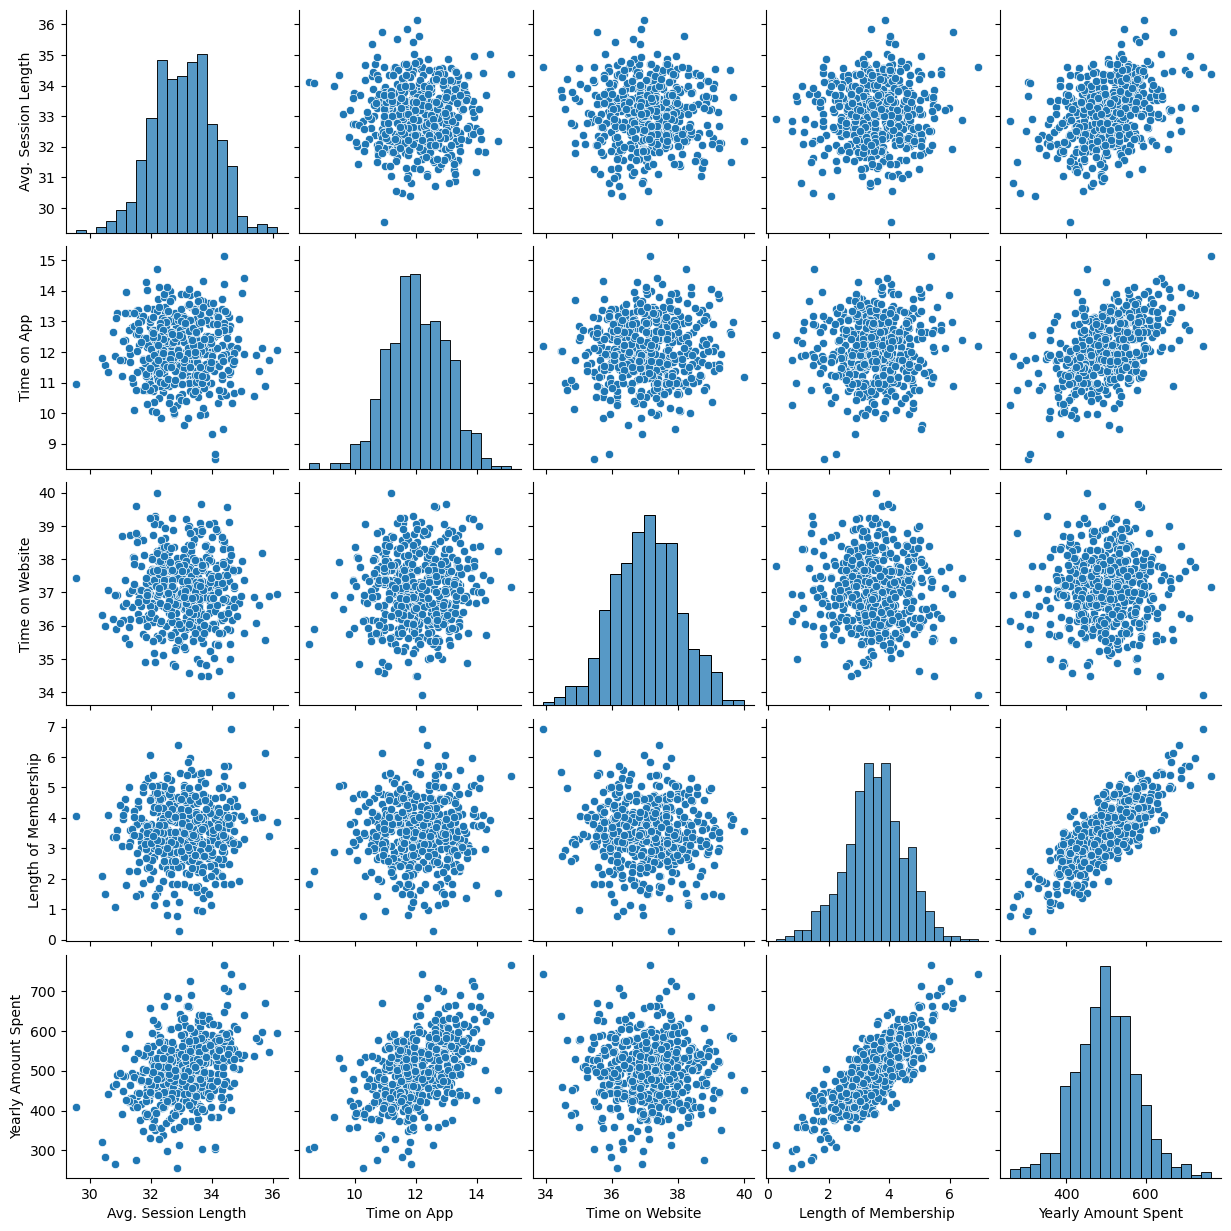

In [14]:
# Exploring relationships across the entire data set
sns.pairplot(customers)
plt.show()

<Axes: >

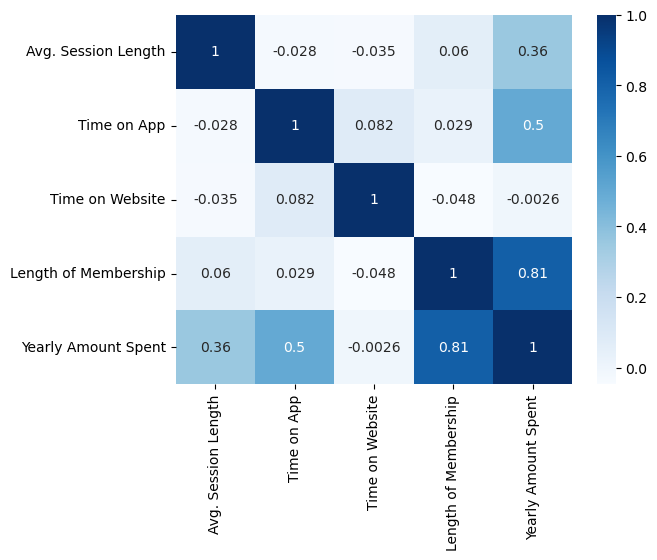

In [16]:
# Heatmap to see numerical correlation (Professional addition)
sns.heatmap(customers.corr(numeric_only=True), annot=True, cmap='Blues')

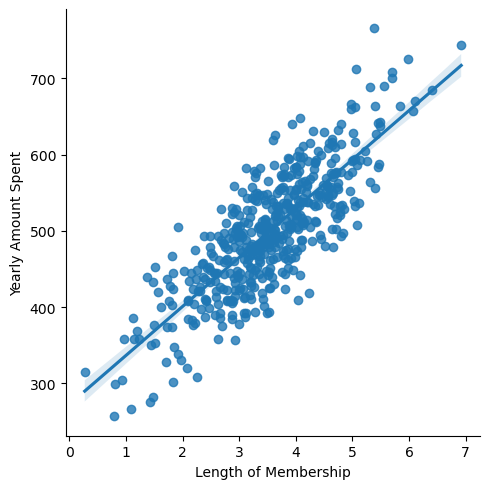

In [15]:
# Creating a linear model plot of Yearly Amount Spent vs. Length of Membership
sns.lmplot(x='Length of Membership', y='Yearly Amount Spent', data=customers)
plt.show()

### 3. Data cleaning 4.Feature engineering 

In [17]:
# Selecting numerical features and the target variable
X = customers[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = customers['Yearly Amount Spent']

### 5. Prepare the data for modeling (Train/Test Split)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### 6. Train the model (Linear Regression)

In [20]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

### 7. Evaluate the model performance

In [21]:
predictions = lm.predict(X_test)

# Print evaluation metrics
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.228148653430845
MSE: 79.81305165097454
RMSE: 8.933815066978639


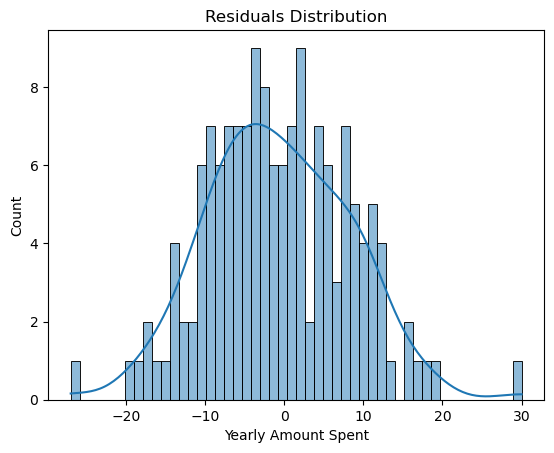

In [22]:
# Plotting residuals to check for normal distribution
sns.histplot((y_test - predictions), bins=50, kde=True)
plt.title('Residuals Distribution')
plt.show()

In [23]:
# Final Conclusion: Displaying the Coefficients
coefficients = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print('\nModel Coefficients:')
print(coefficients)


Model Coefficients:
                      Coefficient
Avg. Session Length     25.981550
Time on App             38.590159
Time on Website          0.190405
Length of Membership    61.279097
